##First steps, Naive linear model,

pour l'instant on charge les données sans utiliser de technique Tf-IDF ou de transformer (BERT fine tunné) seulement des mots clés chargé dans un csv.

Import pour chargement des data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install torchxrayvision -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 56.8 MB/s eta 0:00:00:00:0100:01


We Now start a preprocessing of the dataset,
for now we map the mesh to the targets, for that, we use the already encoded dataset https://github.com/mlmed/torchxrayvision/blob/master/torchxrayvision/datasets.py, (class open-i).

In [ ]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
from pathlib import Path
import torchxrayvision as xrv
import os

# ── 1. Constantes ─────────────────────────────────────────────────
DATA_DIR = "/content/drive/MyDrive/ecgen-radiology"

PATHOLOGIES = [
    "Atelectasis", "Calcified Granuloma", "Cardiomegaly",
    "Effusion", "Emphysema", "Granuloma", "Infiltration",
    "Lung Opacity", "Nodule", "Pneumonia", "Edema"
]



TypeError: 'module' object is not callable

In [8]:
from tqdm.notebook import tqdm  # use this in Colab/Jupyter
# ── 2. Loader XML ─────────────────────────────────────────────────
def load_openi_cohen(data_dir):
    records = []
    for xml_file in tqdm(sorted(Path(data_dir).glob("*.xml"))):
        tree = ET.parse(xml_file)
        root = tree.getroot()
        uid        = root.findtext(".//uId") or xml_file.stem
        indication = root.findtext(".//AbstractText[@Label='INDICATION']") or ""
        findings   = root.findtext(".//AbstractText[@Label='FINDINGS']")   or ""
        records.append({
            "uid":        uid,
            "indication": indication.strip(),
            "findings":   findings.strip(),
        })
    return pd.DataFrame(records)

# ── 3. Charger les rapports ───────────────────────────────────────
df = load_openi_cohen(DATA_DIR)
df["uid"] = "CXR" + df["uid"].astype(str)
import os

# ── Compresser le dossier XML en tar.gz ───────────────────────────
os.system('tar -czf /content/ecgen.tar.gz -C "/content/drive/MyDrive" ecgen-radiology')

# ── 4. Charger les labels via TorchXRayVision ─────────────────────

d_openi = xrv.datasets.Openi_Dataset(
    imgpath="/content/drive/MyDrive/Png",
    xmlpath="/content/ecgen.tar.gz"
)

# ── 5. Construire df_labels avec uid ─────────────────────────────
df_labels = pd.DataFrame(d_openi.labels, columns=d_openi.pathologies)
df_labels = df_labels[PATHOLOGIES].fillna(0).astype(int)
df_labels["Normal"] = (df_labels[PATHOLOGIES].sum(axis=1) == 0).astype(int)
df_labels["uid"] = d_openi.csv["uid"].astype(str).reset_index(drop=True)

# ── 6. Merge sur uid ──────────────────────────────────────────────
df = df[["uid", "indication", "findings"]].merge(df_labels, on="uid", how="inner")

# ── 7. Vérification ───────────────────────────────────────────────
print(f"Shape         : {df.shape}")
print(f"Normaux       : {df['Normal'].sum()}")
print(f"Pathologiques : {(df['Normal'] == 0).sum()}")
print(f"\nDistribution labels:\n{df[PATHOLOGIES + ['Normal']].sum().sort_values(ascending=False)}")
print(df.head())

  0%|          | 0/3955 [00:00<?, ?it/s]

Shape         : (2314, 15)
Normaux       : 1558
Pathologiques : 756

Distribution labels:
Normal                 1558
Granuloma               247
Lung Opacity            238
Atelectasis             186
Calcified Granuloma     136
Cardiomegaly            135
Effusion                 89
Infiltration             61
Emphysema                57
Nodule                   43
Pneumonia                43
Edema                    41
dtype: int64
       uid                                         indication  \
0    CXR10                    XXXX-year-old male, chest pain.   
1   CXR100                                                      
2  CXR1000                          XXXX-year-old male, XXXX.   
3  CXR1001  dyspnea, subjective fevers, arthritis, immigra...   
4  CXR1002                              History of chest pain   

                                            findings  Atelectasis  \
0  The cardiomediastinal silhouette is within nor...            0   
1  Both lungs are clear and expa

In [10]:
output_path = Path('/content/drive/MyDrive/artishow/df_labels.csv')

df.to_csv(output_path,index = False)
print(f"df_meta sauvegardé : {output_path}")


df_meta sauvegardé : /content/drive/MyDrive/artishow/df_labels.csv


In [12]:
df.head()

,uid,indication,findings,Atelectasis,Calcified Granuloma,Cardiomegaly,Effusion,Emphysema,Granuloma,Infiltration,Lung Opacity,Nodule,Pneumonia,Edema,Normal
0,CXR10,"XXXX-year-old male, chest pain.",The cardiomediastinal silhouette is within nor...,0,1,0,0,0,1,0,0,0,0,0,0
1,CXR100,,Both lungs are clear and expanded. Heart and m...,0,0,0,0,0,0,0,0,0,0,0,1
2,CXR1000,"XXXX-year-old male, XXXX.",There is XXXX increased opacity within the rig...,1,0,0,0,0,0,0,1,0,0,0,0
3,CXR1001,"dyspnea, subjective fevers, arthritis, immigra...",Interstitial markings are diffusely prominent ...,0,0,0,0,0,0,0,0,0,0,0,1
4,CXR1002,History of chest pain,,0,0,0,0,0,0,0,0,0,0,0,1


In [ ]:
df[df['Atelectasis'].isna()]

,uid,indication,findings,Atelectasis,Calcified Granuloma,Cardiomegaly,Effusion,Emphysema,Granuloma,Infiltration,Lung Opacity,Nodule,Pneumonia,Edema,Normal


In [16]:
len(df)

2314

Next we are going to vectorize the texts using a very naive and simple approch, TFIDF.
This will allow us to give a first analysis of the dataset and lay down the most simple model (naive logistic regression for example)

In [5]:
# Installer spaCy et télécharger le modèle français
!pip install -U pip setuptools wheel
!pip install -U spacy
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.0 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 58.7 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [6]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [7]:
df

,uid,indication,findings,Atelectasis,Calcified Granuloma,Cardiomegaly,Effusion,Emphysema,Granuloma,Infiltration,Lung Opacity,Nodule,Pneumonia,Edema,Normal
0,CXR10,"XXXX-year-old male, chest pain.",The cardiomediastinal silhouette is within nor...,0,1,0,0,0,1,0,0,0,0,0,0
1,CXR100,,Both lungs are clear and expanded. Heart and m...,0,0,0,0,0,0,0,0,0,0,0,1
2,CXR1000,"XXXX-year-old male, XXXX.",There is XXXX increased opacity within the rig...,1,0,0,0,0,0,0,1,0,0,0,0
3,CXR1001,"dyspnea, subjective fevers, arthritis, immigra...",Interstitial markings are diffusely prominent ...,0,0,0,0,0,0,0,0,0,0,0,1
4,CXR1002,History of chest pain,,0,0,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2309,CXR994,XXXX for one XXXX,The lungs are clear. The cardiomediastinal sil...,0,0,0,0,0,0,0,0,0,0,0,1
2310,CXR995,SP CABG SOB NO RALES,Sternotomy sutures and bypass grafts have been...,0,0,0,0,0,0,0,0,0,0,0,1
2311,CXR996,chest pain.,,0,0,0,0,0,0,0,0,0,0,0,1
2312,CXR998,XXXX-year-old XXXX with pain.,Cardiomediastinal silhouette demonstrates norm...,0,0,0,0,0,0,0,0,0,0,0,1


In [8]:
def removex(text):
    return text.replace("xxxx", "").replace("XXXX", "").replace("year","").replace("years","").replace("old","")


def stopword(text):

    doc = nlp(text)
    filtered_words = [token.text for token in doc if not token.is_stop and not token.is_punct]

    return ' '.join(filtered_words)

def lemmatizer(text):

    doc = nlp(text)
    lemmatized_words = [token.lemma_ for token in doc]

    return ' '.join(lemmatized_words)


def finalpreprocess(text):
    return lemmatizer(stopword(removex(text)))

df['indication'] = df['indication'].apply(lambda x: finalpreprocess(x))
df['findings'] = df['findings'].apply(lambda x: finalpreprocess(x))

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# 1. Séparer features (texte) et target (labels)
label_columns = ['Atelectasis', 'Calcified Granuloma', 'Cardiomegaly',
                 'Effusion', 'Emphysema', 'Granuloma', 'Infiltration',
                 'Lung Opacity', 'Nodule', 'Pneumonia', 'Edema', 'Normal']

# 2. Vectoriser indication
vec_indication = TfidfVectorizer(max_features=2500, stop_words='english', min_df=2)
X_indication = vec_indication.fit_transform(df['indication'])

# 3. Vectoriser findings
vec_findings = TfidfVectorizer(max_features=2500, stop_words='english', min_df=2)
X_findings = vec_findings.fit_transform(df['findings'])

# 4. Concaténer (sparse horizontal stack)
X_data = hstack([X_indication, X_findings])  # Shape: (2314, 5000)

# 5. Target multi-label
y_target = df[label_columns].values  # Shape: (2314, 13)


In [10]:

y_target[14][:]

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

##ANALYSE DES DATA
Maintenant que le dataset est plus compréensible, et vectorisé.

In [11]:
import matplotlib.pyplot as plt

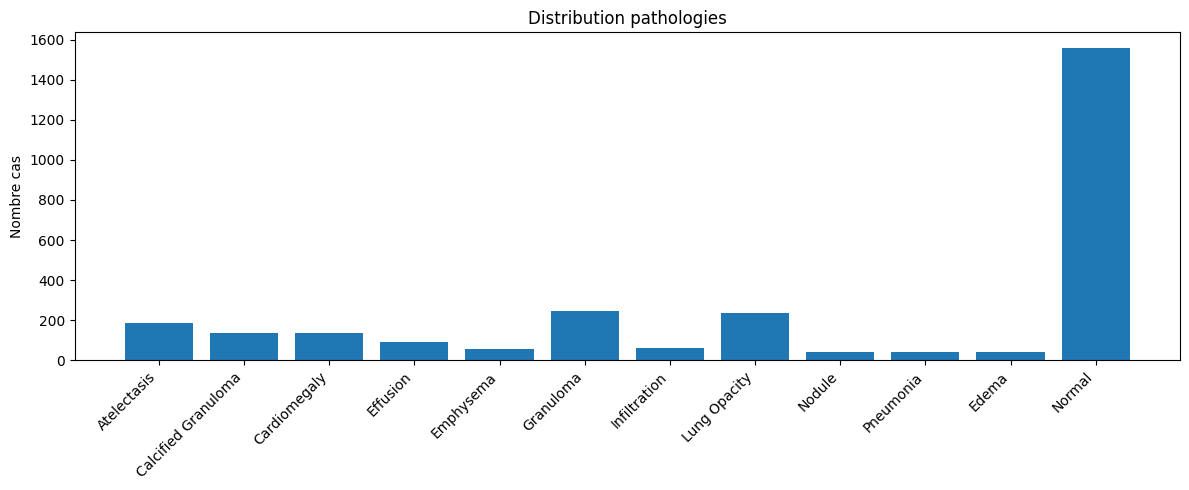

% par pathologie:
[ 8.   5.9  5.8  3.8  2.5 10.7  2.6 10.3  1.9  1.9  1.8 67.3]


In [12]:
label_counts = y_target.sum(axis=0)
label_names = label_columns

plt.figure(figsize=(12, 5))
plt.bar(label_names, label_counts)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Nombre cas')
plt.title('Distribution pathologies')
plt.tight_layout()
plt.show()

print("% par pathologie:")
print((label_counts / len(y_target) * 100).round(1))

<Axes: >

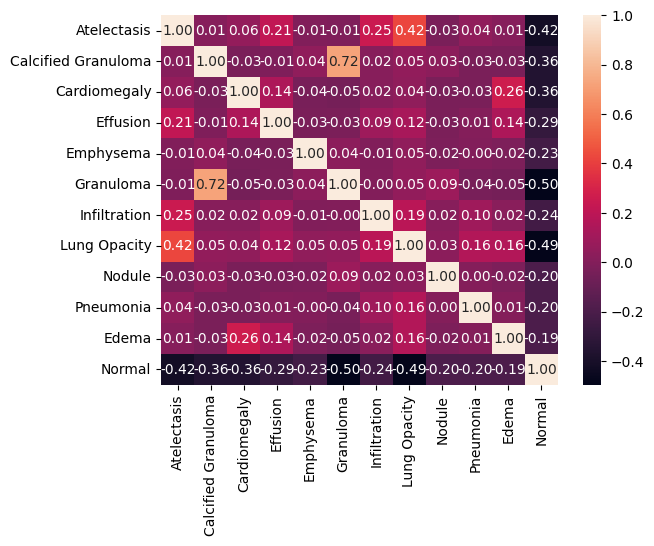

In [13]:
import seaborn as sns
corr = pd.DataFrame(y_target, columns=label_columns).corr()
sns.heatmap(corr, annot=True, fmt='.2f')

In [14]:
feature_names = vec_indication.get_feature_names_out().tolist() + vec_findings.get_feature_names_out().tolist()

for i, label in enumerate(label_columns):
    mask = y_target[:, i] == 1
    X_label = X_data[mask].mean(axis=0).A1
    top_idx = np.argsort(X_label)[-10:][::-1]
    print(f"{label}: {[feature_names[idx] for idx in top_idx]}")

Atelectasis: ['atelectasis', 'pain', 'chest', 'male', 'right', 'leave', 'opacity', 'dyspnea', 'lung', 'breath']
Calcified Granuloma: ['granuloma', 'calcify', 'chest', 'pain', 'female', 'dyspnea', 'stable', 'male', 'right', 'normal']
Cardiomegaly: ['dyspnea', 'pain', 'chest', 'cardiomegaly', 'female', 'stable', 'breath', 'male', 'shortness', 'mild']
Effusion: ['dyspnea', 'right', 'small', 'leave', 'costophrenic', 'male', 'bilateral', 'breath', 'shortness', 'chest']
Emphysema: ['emphysema', 'pain', 'chest', 'dyspnea', 'male', 'size', 'emphysematous', 'lung', 'change', 'heart']
Granuloma: ['chest', 'granuloma', 'pain', 'calcify', 'dyspnea', 'female', 'male', 'stable', 'normal', 'disease']
Infiltration: ['dyspnea', 'breath', 'shortness', 'female', 'infiltrate', 'lobe', 'chest', 'patchy', 'male', 'pain']
Lung Opacity: ['opacity', 'male', 'pain', 'female', 'chest', 'dyspnea', 'right', 'breath', 'leave', 'shortness']
Nodule: ['nodule', 'chest', 'history', 'pain', 'right', 'lobe', 'cm', 'calci

['pain', 'chest', 'normal', 'lung', 'female', 'heart', 'dyspnea', 'clear', 'effusion', 'male', 'pneumothorax', 'pleural', 'size', 'focal', 'limit', 'silhouette', 'consolidation', 'mediastinum', 'unremarkable', 'pulmonary']
[371.14426806 350.36055611 229.63102413 206.64332224 196.19477837
 193.44826361 190.56309833 178.48268814 175.93556973 174.59930738
 172.11815918 169.16969701 162.29929529 146.31837386 132.83514054
 116.62947443 115.65015422 111.68971484 108.37307496 101.09622234]


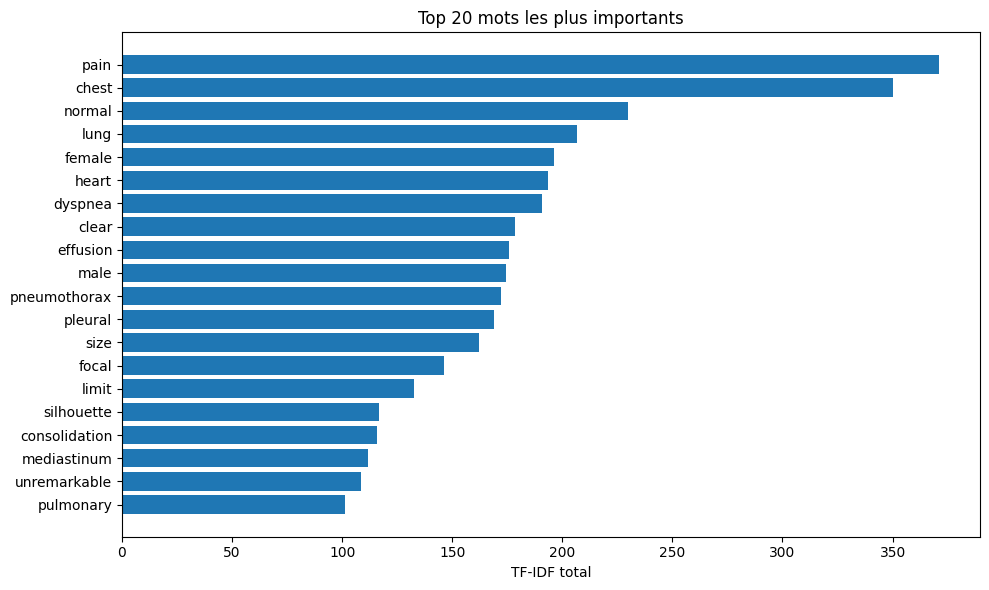

In [15]:
word_importance = np.array(X_data.sum(axis=0)).flatten()
top_idx = np.argsort(word_importance)[-20:][::-1]
top_words = [feature_names[idx] for idx in top_idx]
top_values = word_importance[top_idx]
print(top_words)
print(top_values)

plt.figure(figsize=(10, 6))
plt.barh(top_words, top_values)
plt.xlabel('TF-IDF total')
plt.title('Top 20 mots les plus importants')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
# Sparsité
sparsity = 1 - (X_data.nnz / (X_data.shape[0] * X_data.shape[1]))
print(f"Sparsité: {sparsity:.2%}")

# Dimension
print(f"Shape: {X_data.shape}")
print(f"Mémoire: {X_data.data.nbytes / 1e6:.1f} MB")

Sparsité: 98.33%
Shape: (2314, 1074)
Mémoire: 0.3 MB


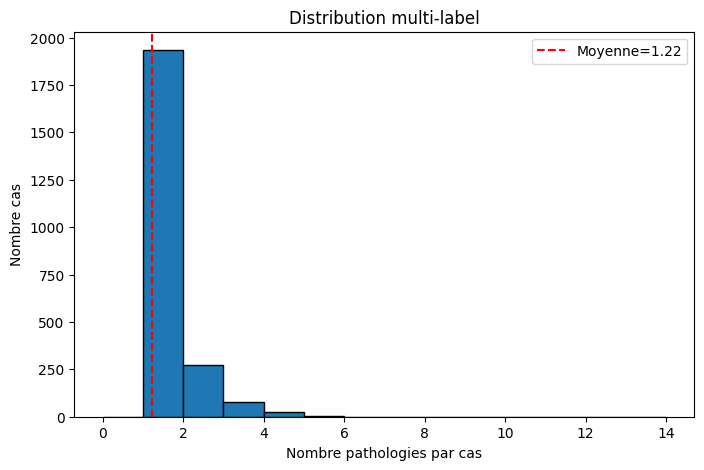

In [17]:
n_labels = y_target.sum(axis=1)
plt.figure(figsize=(8, 5))
plt.hist(n_labels, bins=range(0, 15), edgecolor='black')
plt.xlabel('Nombre pathologies par cas')
plt.ylabel('Nombre cas')
plt.title('Distribution multi-label')
plt.axvline(n_labels.mean(), color='red', linestyle='--', label=f'Moyenne={n_labels.mean():.2f}')
plt.legend()
plt.show()

Text(0.5, 1.0, 't-SNE: Rouge=Normal, Bleu=Pathology')

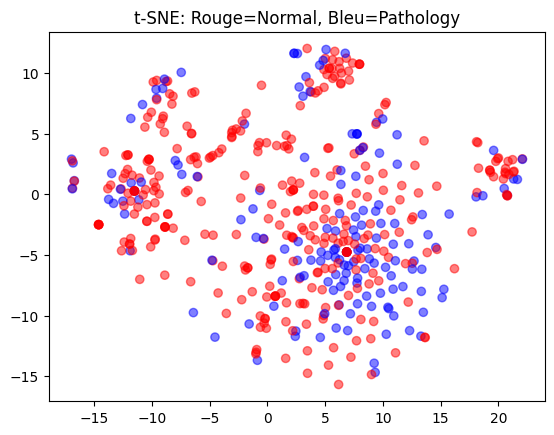

In [18]:
from sklearn.manifold import TSNE

# Sample 500 documents (t-SNE lent sur 2314)
idx = np.random.choice(X_data.shape[0], 500, replace=False)
X_sample = X_data[idx].toarray()
y_sample = y_target[idx]

tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X_sample)

# Color par Normal vs Pathology
colors = ['red' if y[11]==1 else 'blue' for y in y_sample]
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, alpha=0.5)
plt.title('t-SNE: Rouge=Normal, Bleu=Pathology')

Interprétation Résultats
t-SNE : Pas de Séparation Claire

Normal (rouge) et Pathology (bleu) pas mal mélangés, on arrive quand mêle à trouver des "zones", comme le diagramme reste une projection, la regression logistique devrais quand même avoir de bon resultat :
→ Classification difficile avec TF-IDF seul
→ BERT devrait mieux capturer nuances ("no evidence pneumonia" vs "pneumonia")


Top 20 Mots : Trop Génériques

"pain", "chest", "year", "old" → présents partout
→ TF-IDF capte mots fréquents, pas contexte médical
→ Besoin embeddings contextuels (BERT)


Mots par Pathologie : Mixte
Discriminants clairs :

Atelectasis → "atelectasis"
Granuloma → "granuloma", "calcify"
Nodule → "nodule", "cm"

Génériques (difficiles) :

Normal → "pain", "chest", "year" (comme pathologies!)
Effusion → "dyspnea", "right" (peu spécifique)


 Conclusion
Baseline TF-IDF attendu : AUC 0.70-0.75

Pathologies avec mots spécifiques : OK
Pathologies subtiles (Normal, Effusion) : faible
BERT nécessaire pour contexte ("no atelectasis" ≠ "atelectasis")

##Binary Logistic Regression

We first implemnt using TF-IDF a logistic regression, One vs all.

In [19]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

y_normal = df['Normal']

X_train, X_test, y_train, y_test = train_test_split(
X_data, y_normal, test_size=0.2, random_state=41)

model = make_pipeline(LogisticRegression())


In [20]:
from sklearn.model_selection import cross_validate
cv_results = cross_validate(model, X_train, y_train, cv=5, scoring='roc_auc')
cv = cv_results['test_score']
print(f"{cv.mean()} +/- {cv.std()}")

0.9398043636143557 +/- 0.004130104334733431


In [21]:

clf = model.fit(X_train, y_train)

model.score(X_test, y_test)

0.8747300215982722

In [22]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])

np.float64(0.9498512301270094)

we obtain a quite ok result it seems compare to a dummy classifier guessing always normal

In [23]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_clf.score(X_test, y_test)

0.6997840172786177

lets try to do better by playing on the parameters of regularization.
as we see we have a huge difference between the cv results on the dataset and on the test set.
The model severly overfitt

In [24]:
y_test

,Normal
1815,0
1817,1
1890,1
1981,1
141,0
...,...
2099,1
1597,0
2239,0
1872,0


In [26]:
from sklearn.preprocessing import MaxAbsScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

pipe = make_pipeline(
    MaxAbsScaler(),
    LogisticRegression(max_iter=1000, solver='saga')
)

param_dist = {
    'logisticregression__C': np.logspace(-4, 4, 50),
    'logisticregression__penalty': ['l1', 'l2', 'elasticnet'],
    'logisticregression__l1_ratio': np.linspace(0, 1, 10)
}

search = RandomizedSearchCV(
    pipe, param_dist,
    n_iter=30, cv=5,
    scoring='roc_auc',
    random_state=42, n_jobs=-1
)

search.fit(X_train, y_train)

print(f"Best params: {search.best_params_}")
print(f"Best AUC CV: {search.best_score_:.4f}")
print(f"Test AUC:    {roc_auc_score(y_test, search.predict_proba(X_test)[:, 1]):.4f}")

Best params: {'logisticregression__penalty': 'l1', 'logisticregression__l1_ratio': np.float64(0.7777777777777777), 'logisticregression__C': np.float64(0.8286427728546842)}
Best AUC CV: 0.9528
Test AUC:    0.9601


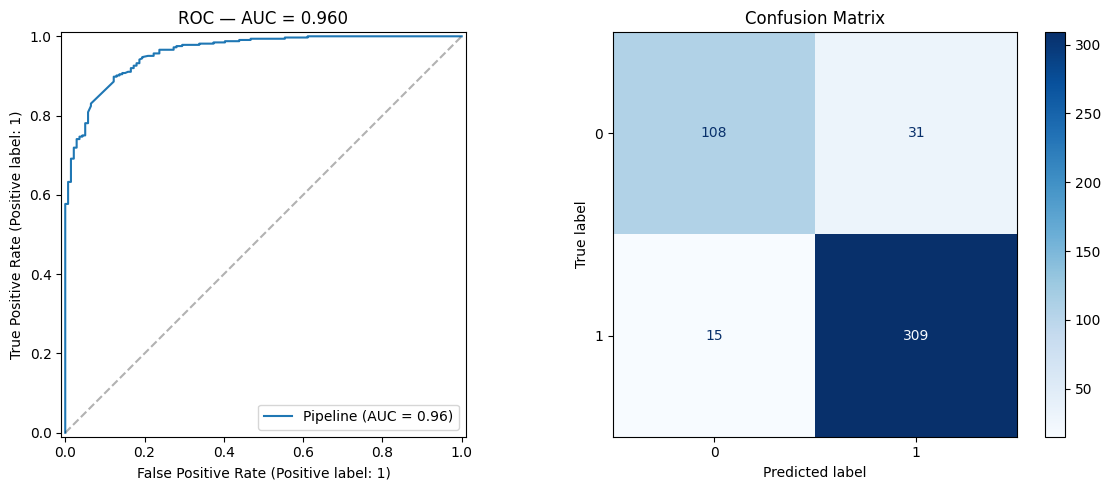

              precision    recall  f1-score   support

  Not Normal       0.88      0.78      0.82       139
      Normal       0.91      0.95      0.93       324

    accuracy                           0.90       463
   macro avg       0.89      0.87      0.88       463
weighted avg       0.90      0.90      0.90       463



In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, classification_report

best = search.best_estimator_
y_proba = best.predict_proba(X_test)[:, 1]
y_pred = best.predict(X_test)

# ROC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_estimator(best, X_test, y_test, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title(f"ROC — AUC = {roc_auc_score(y_test, y_proba):.3f}")

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(best, X_test, y_test, ax=axes[1], cmap='Blues')
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Not Normal', 'Normal']))

Analyse finale — Classification binaire Normal vs. Pathologie
Le modèle atteint une AUC de 0.96, ce qui confirme un excellent ranking : il sait très bien ordonner les rapports du plus pathologique au plus normal. L'accuracy à 0.90 dépasse largement le dummy (0.70), donc la performance est réelle.
Le point faible est visible dans la confusion matrix : 31 faux positifs (rapports pathologiques prédits Normal) et 15 faux négatifs (rapports normaux prédits pathologiques). En contexte clinique, les 31 FP sont les plus préoccupants — ce sont des pathologies manquées. Le recall de Not Normal à 0.78 le confirme : le modèle rate 22% des cas pathologiques. Si tu voulais optimiser pour le médical, tu baisserais le seuil de décision pour favoriser la sensibilité (recall Not Normal) au prix de plus de faux positifs.
Cela dit, cette performance élevée reste attendue vu la quasi-circularité labels ↔ texte. Le vrai test de généralisation viendra avec le multi-label.

Adaptation au multi-label — ce qui change :
Le passage clé est conceptuel : tu ne prédis plus une classe, mais 10 labels indépendants (Atelectasis, Cardiomegaly, Effusion, etc.), chacun pouvant être 0 ou 1 simultanément. Concrètement :
Structure — OneVsRestClassifier wrappé autour de ta pipeline actuelle. Chaque pathologie obtient son propre classifieur binaire, avec son propre seuil optimal.
Target — y passe d'une colonne unique à une matrice (2314, 10). Chaque ligne peut avoir plusieurs 1.
Métriques — L'AUC unique devient une AUC par pathologie + une macro-average. Le classification_report sera par label. Les classes rares (Pneumonia, Hernia) auront des scores bien plus faibles que le binaire actuel.
Régularisation — Le C optimal sera probablement différent par pathologie. Tu pourrais faire un RandomizedSearchCV par label, ou garder un C global comme premier jet.
Features — Les mêmes TF-IDF fonctionnent, mais tu peux expérimenter avec max_features (augmenter pour capter du vocabulaire spécifique à des pathologies rares) et ngram_range=(1,2) (bigrams comme "pleural effusion" deviendront discriminants pour des classes spécifiques). Tu peux aussi tester de retirer indication et garder uniquement findings, car l'indication contient surtout le motif de consultation, pas le diagnostic.
Déséquilibre — Le problème va s'aggraver fortement. Certaines pathologies ont moins de 5% de positifs. Tu devras utiliser class_weight='balanced' dans la LogisticRegression, ou sampler avec SMOTE sur chaque sous-problème binaire.

In [29]:
search = RandomizedSearchCV(
    pipe,
    [
        # L1 / L2 sans l1_ratio
        {
            'onevsrestclassifier__estimator__C': np.logspace(-4, 4, 50),
            'onevsrestclassifier__estimator__penalty': ['l1', 'l2'],
        },
        # ElasticNet avec l1_ratio
        {
            'onevsrestclassifier__estimator__C': np.logspace(-4, 4, 50),
            'onevsrestclassifier__estimator__penalty': ['elasticnet'],
            'onevsrestclassifier__estimator__l1_ratio': np.linspace(0.1, 0.9, 9),
        }
    ],
    n_iter=15, cv=3,
    scoring='f1_macro',
    random_state=42, n_jobs=-1
)

X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=0.3, random_state=42
)

search.fit(X_sub, y_sub)

best_params = search.best_params_
pipe.set_params(**best_params)
pipe.fit(X_train, y_train)

print(f"Best params: {search.best_params_}")
print(f"Best macro AUC CV: {search.best_score_:.4f}")

Best params: {'onevsrestclassifier__estimator__penalty': 'elasticnet', 'onevsrestclassifier__estimator__l1_ratio': np.float64(0.8), 'onevsrestclassifier__estimator__C': np.float64(5.428675439323859)}
Best macro AUC CV: 0.8893


In [30]:
best = search.best_estimator_
y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)

# AUC par pathologie
print("=== AUC par pathologie ===")
aucs = {}
for i, col in enumerate(label_columns):
    n_pos = y_test[col].sum()
    if n_pos > 0:
        auc = roc_auc_score(y_test[col], y_proba[:, i])
        aucs[col] = auc
        print(f"  {col:25s}  AUC={auc:.3f}  (n+={int(n_pos)})")
    else:
        print(f"  {col:25s}  --- pas de positifs dans test ---")

macro_auc = roc_auc_score(y_test, y_proba, average='macro')
print(f"\nMacro AUC: {macro_auc:.4f}")
print("\n" + classification_report(y_test, y_pred, target_names=label_columns, zero_division=0))

=== AUC par pathologie ===
  Atelectasis                AUC=0.956  (n+=43)
  Calcified Granuloma        AUC=0.969  (n+=33)
  Cardiomegaly               AUC=0.923  (n+=17)
  Effusion                   AUC=0.906  (n+=19)
  Emphysema                  AUC=0.705  (n+=11)
  Granuloma                  AUC=0.981  (n+=54)
  Infiltration               AUC=0.893  (n+=14)
  Lung Opacity               AUC=0.975  (n+=52)
  Nodule                     AUC=0.940  (n+=6)
  Pneumonia                  AUC=0.806  (n+=9)
  Edema                      AUC=0.927  (n+=3)
  Normal                     AUC=0.928  (n+=312)

Macro AUC: 0.9092

                     precision    recall  f1-score   support

        Atelectasis       0.57      0.77      0.65        43
Calcified Granuloma       0.78      0.88      0.83        33
       Cardiomegaly       0.41      0.76      0.53        17
           Effusion       0.60      0.47      0.53        19
          Emphysema       0.40      0.36      0.38        11
          Gr

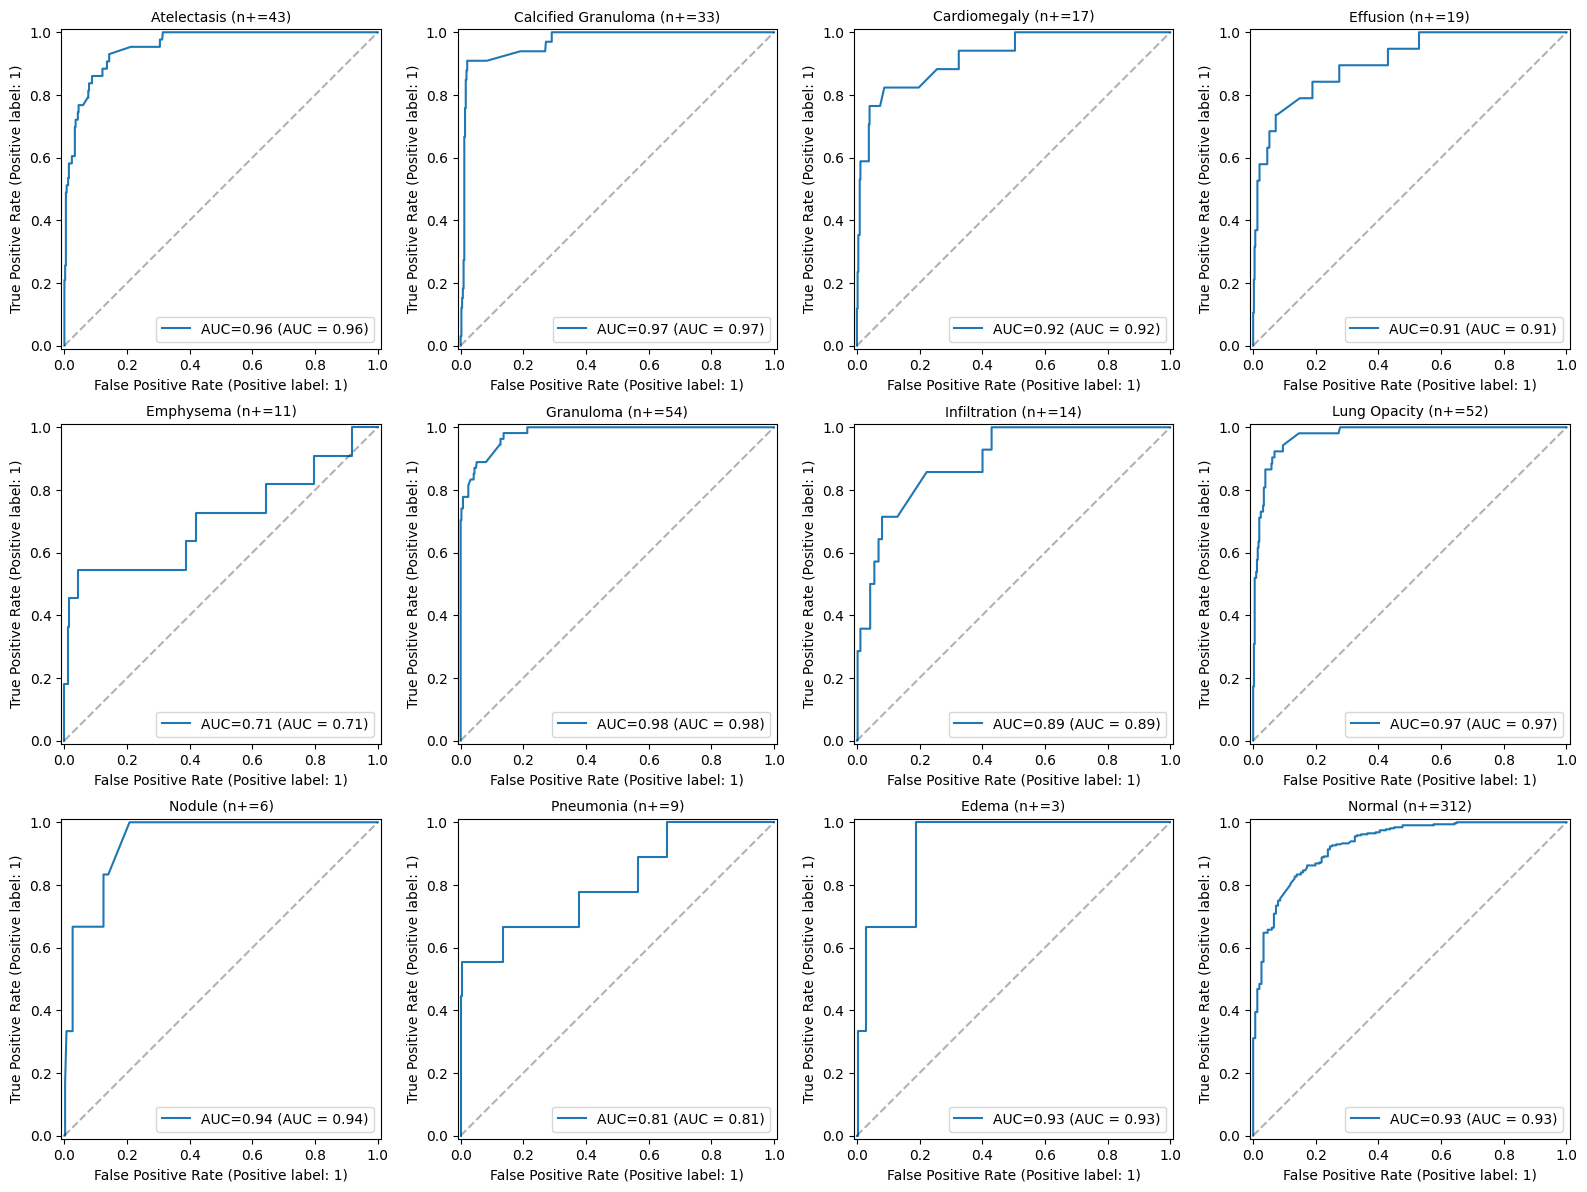

In [31]:
# ROC curves
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(label_columns):
    n_pos = y_test[col].sum()
    if n_pos > 0:
        RocCurveDisplay.from_predictions(
            y_test[col], y_proba[:, i], ax=axes[i], name=f"AUC={aucs[col]:.2f}"
        )
    axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[i].set_title(f"{col} (n+={int(n_pos)})", fontsize=10)

plt.tight_layout()
plt.show()

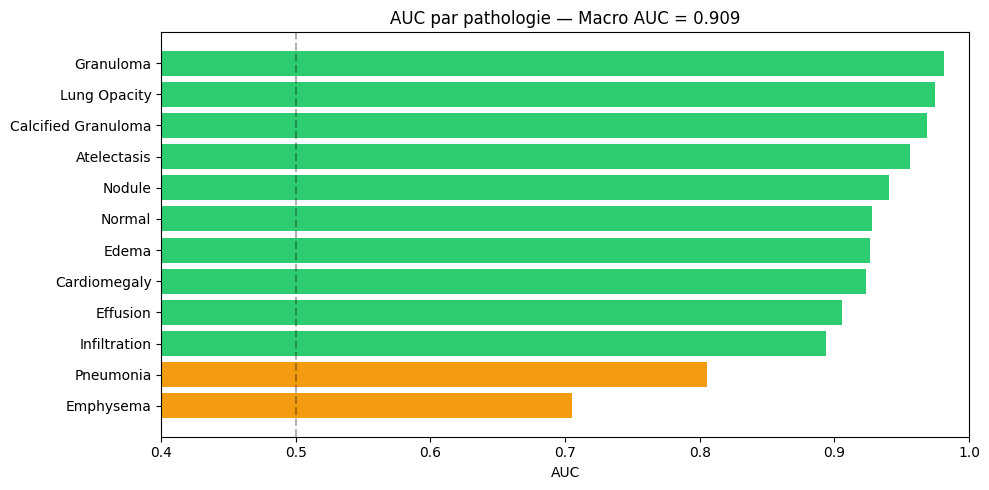

In [32]:
# Barplot AUC comparatif
fig, ax = plt.subplots(figsize=(10, 5))
sorted_aucs = dict(sorted(aucs.items(), key=lambda x: x[1]))
colors = ['#e74c3c' if v < 0.7 else '#f39c12' if v < 0.85 else '#2ecc71' for v in sorted_aucs.values()]
ax.barh(list(sorted_aucs.keys()), list(sorted_aucs.values()), color=colors)
ax.axvline(x=0.5, color='k', linestyle='--', alpha=0.3, label='random')
ax.set_xlim(0.4, 1.0)
ax.set_xlabel('AUC')
ax.set_title(f'AUC par pathologie — Macro AUC = {macro_auc:.3f}')
plt.tight_layout()
plt.show()